# Crosswalk Detection — Deployment
Deploy the UNet model (trained on University City) to new neighborhood mosaics.

**Pre-requisites:**
- Mosaics pre-processed in ArcGIS: `middle.tif`, `south.tif`, `upper-middle.tif`
- Mosaics placed in Google Drive: `My Drive/musa-deploy/`
- Trained model: `models/best_unet.pt` (in the repo)

## 1. Setup

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!git clone https://github.com/zyang91/musa-practicum.git
%cd /content/musa-practicum

Cloning into 'musa-practicum'...
remote: Enumerating objects: 338, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 338 (delta 17), reused 32 (delta 10), pack-reused 294 (from 2)
Receiving objects: 100% (338/338), 218.96 MiB | 65.16 MiB/s, done.
Resolving deltas: 100% (117/117), done.
/content/musa-practicum


In [14]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.74 KiB | 1.74 MiB/s, done.
From https://github.com/zyang91/musa-practicum
   d00f17e..5bc9b8d  main       -> origin/main
Updating d00f17e..5bc9b8d
Fast-forward
 deploy.ipynb | 846 ++++++++++++++++++++++++-----------------------------------
 1 file changed, 342 insertions(+), 504 deletions(-)


In [15]:
!pip -q install rasterio segmentation-models-pytorch geopandas

In [16]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 2. Config
Set your Google Drive paths here.

In [17]:
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────
DRIVE_INPUT = Path('/content/drive/MyDrive/musa-deploy')
MODEL_PATH = Path('models/best_unet.pt')
OUTPUT_DIR = Path('/content/drive/MyDrive/musa-deploy/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Input mosaics
MOSAICS = [
    DRIVE_INPUT / 'middle.tif',
    DRIVE_INPUT / 'south.tif',
    DRIVE_INPUT / 'upper-middle.tif',
]

# ── Prediction params ────────────────────────────────────────
PATCH_SIZE = 256
STRIDE = 128
THRESHOLD = 0.45
BATCH_SIZE = 16

# ── Post-processing params ──────────────────────────────────
MIN_PIXELS = 200

# Verify files exist
print('Model:', MODEL_PATH, '→', MODEL_PATH.exists())
for m in MOSAICS:
    print(f'{m.name}: {m.exists()}')

Model: models/best_unet.pt → True
middle.tif: True
south.tif: True
upper-middle.tif: True


## 3. Load Model

In [18]:
import numpy as np
import segmentation_models_pytorch as smp

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights=None,
    in_channels=3,
    classes=1,
)
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
else:
    model.load_state_dict(ckpt)
model.to(DEVICE).eval()
print('Model loaded on', DEVICE)

Model loaded on cuda


## 4. Prediction Functions

In [19]:
import rasterio
from rasterio.windows import Window


def normalize_img(img):
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img /= 255.0
    return np.clip(img, 0.0, 1.0)


def pad_patch(arr, patch_size):
    c, h, w = arr.shape
    out = np.zeros((c, patch_size, patch_size), dtype=arr.dtype)
    out[:, :h, :w] = arr
    return out, h, w


def tile_positions(full_size, patch_size, stride):
    if full_size <= patch_size:
        return [0]
    positions = list(range(0, full_size - patch_size + 1, stride))
    if positions[-1] != full_size - patch_size:
        positions.append(full_size - patch_size)
    return positions


def predict_mosaic(input_path, output_dir, model, threshold=0.45,
                   patch_size=256, stride=128, batch_size=16):
    """Run sliding-window prediction on a mosaic. Returns (prob_path, bin_path)."""
    input_path = Path(input_path)
    output_dir = Path(output_dir)
    stem = input_path.stem

    prob_out = output_dir / f'{stem}_prob.tif'
    bin_out = output_dir / f'{stem}_bin.tif'

    with rasterio.open(input_path) as src:
        profile = src.profile.copy()
        height, width = src.height, src.width
        print(f'  Raster: {width} x {height}, bands={src.count}, dtype={src.dtypes}, crs={src.crs}')

        ys = tile_positions(height, patch_size, stride)
        xs = tile_positions(width, patch_size, stride)
        n_total = len(xs) * len(ys)
        print(f'  Windows: {n_total}')

        prob_sum = np.zeros((height, width), dtype=np.float32)
        prob_count = np.zeros((height, width), dtype=np.float32)

        # Collect windows
        windows = []
        for y in ys:
            for x in xs:
                win_h = min(patch_size, height - y)
                win_w = min(patch_size, width - x)
                windows.append((x, y, win_w, win_h))

        n_done = 0
        for batch_start in range(0, len(windows), batch_size):
            batch_specs = windows[batch_start:batch_start + batch_size]
            patches = []
            orig_sizes = []

            for x, y, win_w, win_h in batch_specs:
                window = Window(x, y, win_w, win_h)
                patch = src.read([1, 2, 3], window=window)
                patch, h0, w0 = pad_patch(patch, patch_size)
                patch = normalize_img(patch)
                patches.append(patch)
                orig_sizes.append((h0, w0))

            tensor = torch.from_numpy(np.stack(patches)).to(DEVICE)
            with torch.no_grad():
                logits = model(tensor)
                probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()

            for i, (x, y, _, _) in enumerate(batch_specs):
                h0, w0 = orig_sizes[i]
                prob_sum[y:y+h0, x:x+w0] += probs[i, :h0, :w0]
                prob_count[y:y+h0, x:x+w0] += 1.0

            n_done += len(batch_specs)
            if n_done % 500 == 0 or n_done == n_total:
                print(f'    {n_done}/{n_total} windows ({n_done*100//n_total}%)')

    prob_avg = prob_sum / np.maximum(prob_count, 1e-6)
    pred_bin = (prob_avg >= threshold).astype(np.uint8)

    # Save probability raster
    prob_profile = profile.copy()
    prob_profile.update(dtype='float32', count=1, compress='lzw', BIGTIFF='YES')
    with rasterio.open(prob_out, 'w', **prob_profile) as dst:
        dst.write(prob_avg.astype(np.float32), 1)

    # Save binary raster
    bin_profile = profile.copy()
    bin_profile.update(dtype='uint8', count=1, compress='lzw', nodata=0, BIGTIFF='YES')
    with rasterio.open(bin_out, 'w', **bin_profile) as dst:
        dst.write(pred_bin, 1)

    pos_px = int(pred_bin.sum())
    print(f'  Positive pixels: {pos_px}')
    print(f'  Saved: {prob_out.name}, {bin_out.name}')
    return prob_out, bin_out

## 5. Post-processing Functions

In [20]:
from rasterio.features import shapes
from scipy import ndimage
import geopandas as gpd
from shapely.geometry import shape


def postprocess(bin_path, output_dir, min_pixels=200):
    """Clean binary raster and vectorize to polygons."""
    bin_path = Path(bin_path)
    output_dir = Path(output_dir)
    stem = bin_path.stem.replace('_bin', '')

    cleaned_path = output_dir / f'{stem}_bin_cleaned.tif'
    gpkg_path = output_dir / f'{stem}_crosswalks.gpkg'
    shp_path = output_dir / f'{stem}_crosswalks.shp'

    with rasterio.open(bin_path) as src:
        mask = src.read(1)
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs

    mask = (mask > 0).astype(np.uint8)
    print(f'  Original positive pixels: {int(mask.sum())}')

    # Remove small components
    labeled, num = ndimage.label(mask)
    if num > 0:
        counts = np.bincount(labeled.ravel())
        keep = counts >= min_pixels
        keep[0] = False
        mask = keep[labeled].astype(np.uint8)

    # Morphological closing
    structure = np.ones((3, 3), dtype=np.uint8)
    mask = ndimage.binary_closing(mask.astype(bool), structure=structure).astype(np.uint8)
    print(f'  Cleaned positive pixels:  {int(mask.sum())}')

    # Save cleaned raster
    out_profile = {
        'driver': 'GTiff', 'height': mask.shape[0], 'width': mask.shape[1],
        'count': 1, 'dtype': 'uint8', 'crs': crs, 'transform': transform,
        'compress': 'lzw', 'BIGTIFF': 'YES', 'tiled': True,
        'blockxsize': 256, 'blockysize': 256, 'nodata': 0,
    }
    with rasterio.open(cleaned_path, 'w', **out_profile) as dst:
        dst.write(mask, 1)

    # Vectorize
    geoms = []
    for geom, value in shapes(mask, mask=(mask == 1), transform=transform):
        if value == 1:
            geoms.append(shape(geom))

    if not geoms:
        print('  No polygons found.')
        return None

    gdf = gpd.GeoDataFrame({'value': 1}, geometry=geoms, crs=crs, index=range(len(geoms)))
    gdf['area_sqft'] = gdf.geometry.area
    gdf = gdf[gdf.geometry.notnull() & (gdf['area_sqft'] > 0)].reset_index(drop=True)

    gdf.to_file(gpkg_path, driver='GPKG')
    gdf.to_file(shp_path)

    print(f'  Polygons: {len(gdf)}')
    print(f'  Saved: {gpkg_path.name}, {shp_path.name}')
    return gdf

## 6. Run All Mosaics

In [21]:
results = {}

for mosaic_path in MOSAICS:
    name = mosaic_path.stem
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')

    if not mosaic_path.exists():
        print(f'  ✗ File not found: {mosaic_path}')
        continue

    # Predict
    print(f'\n  [Step 1] Predicting...')
    prob_path, bin_path = predict_mosaic(
        mosaic_path, OUTPUT_DIR, model,
        threshold=THRESHOLD, patch_size=PATCH_SIZE,
        stride=STRIDE, batch_size=BATCH_SIZE,
    )

    # Post-process
    print(f'\n  [Step 2] Post-processing...')
    gdf = postprocess(bin_path, OUTPUT_DIR, min_pixels=MIN_PIXELS)
    results[name] = gdf

    print(f'\n  ✓ {name} done')

print(f'\n{"="*60}')
print('All done!')
for name, gdf in results.items():
    n = len(gdf) if gdf is not None else 0
    print(f'  {name:20s} → {n} crosswalk polygons')


  middle

  [Step 1] Predicting...
  Raster: 42240 x 31680, bands=3, dtype=('uint8', 'uint8', 'uint8'), crs=EPSG:2272
  Windows: 81263
    2000/81263 windows (2%)
    4000/81263 windows (4%)
    6000/81263 windows (7%)
    8000/81263 windows (9%)
    10000/81263 windows (12%)
    12000/81263 windows (14%)
    14000/81263 windows (17%)
    16000/81263 windows (19%)
    18000/81263 windows (22%)
    20000/81263 windows (24%)
    22000/81263 windows (27%)
    24000/81263 windows (29%)
    26000/81263 windows (31%)
    28000/81263 windows (34%)
    30000/81263 windows (36%)
    32000/81263 windows (39%)
    34000/81263 windows (41%)
    36000/81263 windows (44%)
    38000/81263 windows (46%)
    40000/81263 windows (49%)
    42000/81263 windows (51%)
    44000/81263 windows (54%)
    46000/81263 windows (56%)
    48000/81263 windows (59%)
    50000/81263 windows (61%)
    52000/81263 windows (63%)
    54000/81263 windows (66%)
    56000/81263 windows (68%)
    58000/81263 windows (71%)
  

  Polygons: 1495
  Saved: middle_crosswalks.gpkg, middle_crosswalks.shp

  ✓ middle done

  south

  [Step 1] Predicting...
  Raster: 73920 x 21120, bands=3, dtype=('uint8', 'uint8', 'uint8'), crs=EPSG:2272
  Windows: 94628
    2000/94628 windows (2%)
    4000/94628 windows (4%)
    6000/94628 windows (6%)
    8000/94628 windows (8%)
    10000/94628 windows (10%)
    12000/94628 windows (12%)
    14000/94628 windows (14%)
    16000/94628 windows (16%)
    18000/94628 windows (19%)
    20000/94628 windows (21%)
    22000/94628 windows (23%)
    24000/94628 windows (25%)
    26000/94628 windows (27%)
    28000/94628 windows (29%)
    30000/94628 windows (31%)
    32000/94628 windows (33%)
    34000/94628 windows (35%)
    36000/94628 windows (38%)
    38000/94628 windows (40%)
    40000/94628 windows (42%)
    42000/94628 windows (44%)
    44000/94628 windows (46%)
    46000/94628 windows (48%)
    48000/94628 windows (50%)
    50000/94628 windows (52%)
    52000/94628 windows (54%)
    

## 7. Quick Preview

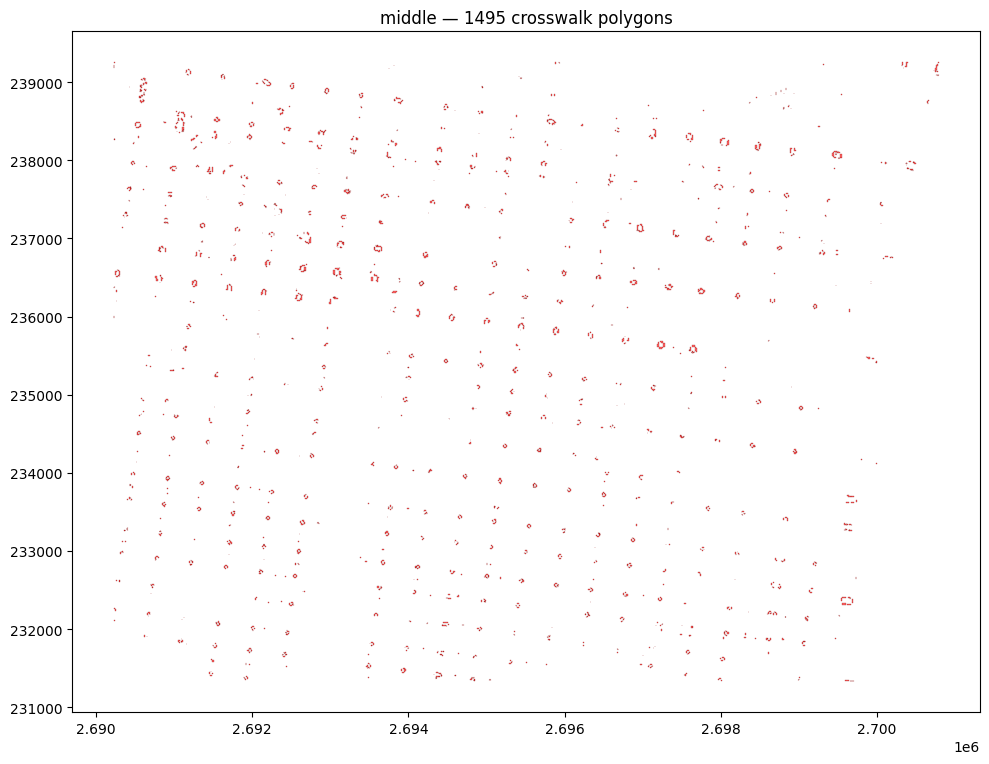

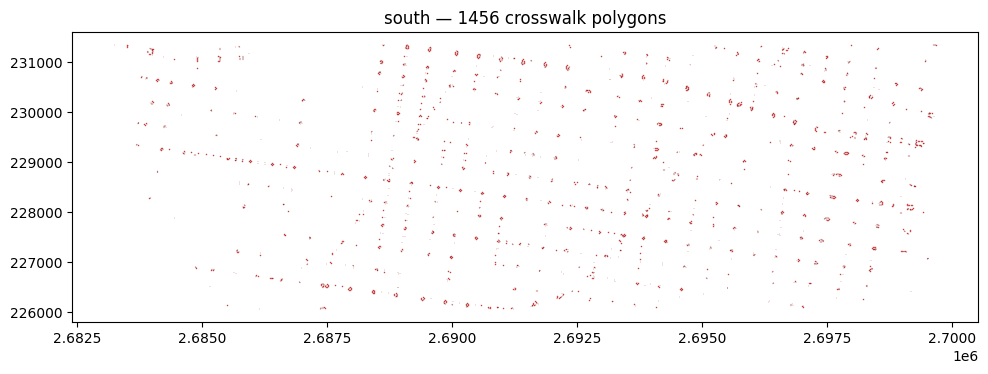

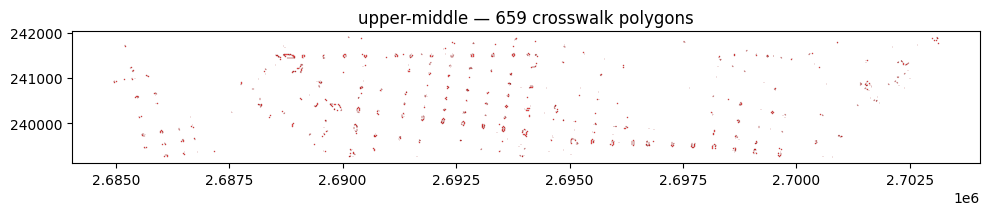

In [22]:
import matplotlib.pyplot as plt

for name, gdf in results.items():
    if gdf is None or len(gdf) == 0:
        continue
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf.plot(ax=ax, color='red', edgecolor='darkred', linewidth=0.3, alpha=0.6)
    ax.set_title(f'{name} — {len(gdf)} crosswalk polygons')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

## 8. Check Output Files

In [23]:
import os
print(f'Output directory: {OUTPUT_DIR}')
print()
for f in sorted(OUTPUT_DIR.glob('*')):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name:40s} {size_mb:.1f} MB')

Output directory: /content/drive/MyDrive/musa-deploy/results

  middle_bin.tif                           17.4 MB
  middle_bin_cleaned.tif                   9.0 MB
  middle_crosswalks.cpg                    0.0 MB
  middle_crosswalks.dbf                    0.1 MB
  middle_crosswalks.gpkg                   4.0 MB
  middle_crosswalks.prj                    0.0 MB
  middle_crosswalks.shp                    2.9 MB
  middle_crosswalks.shx                    0.0 MB
  middle_prob.tif                          4096.0 MB
  south_bin.tif                            20.2 MB
  south_bin_cleaned.tif                    10.4 MB
  south_crosswalks.cpg                     0.0 MB
  south_crosswalks.dbf                     0.1 MB
  south_crosswalks.gpkg                    3.7 MB
  south_crosswalks.prj                     0.0 MB
  south_crosswalks.shp                     2.7 MB
  south_crosswalks.shx                     0.0 MB
  south_prob.tif                           6232.1 MB
  upper-middle_bin.tif       